## Plan of Action


1-we will do improvements in our previous training pipeline

2-the nn module

3-torch.optim module

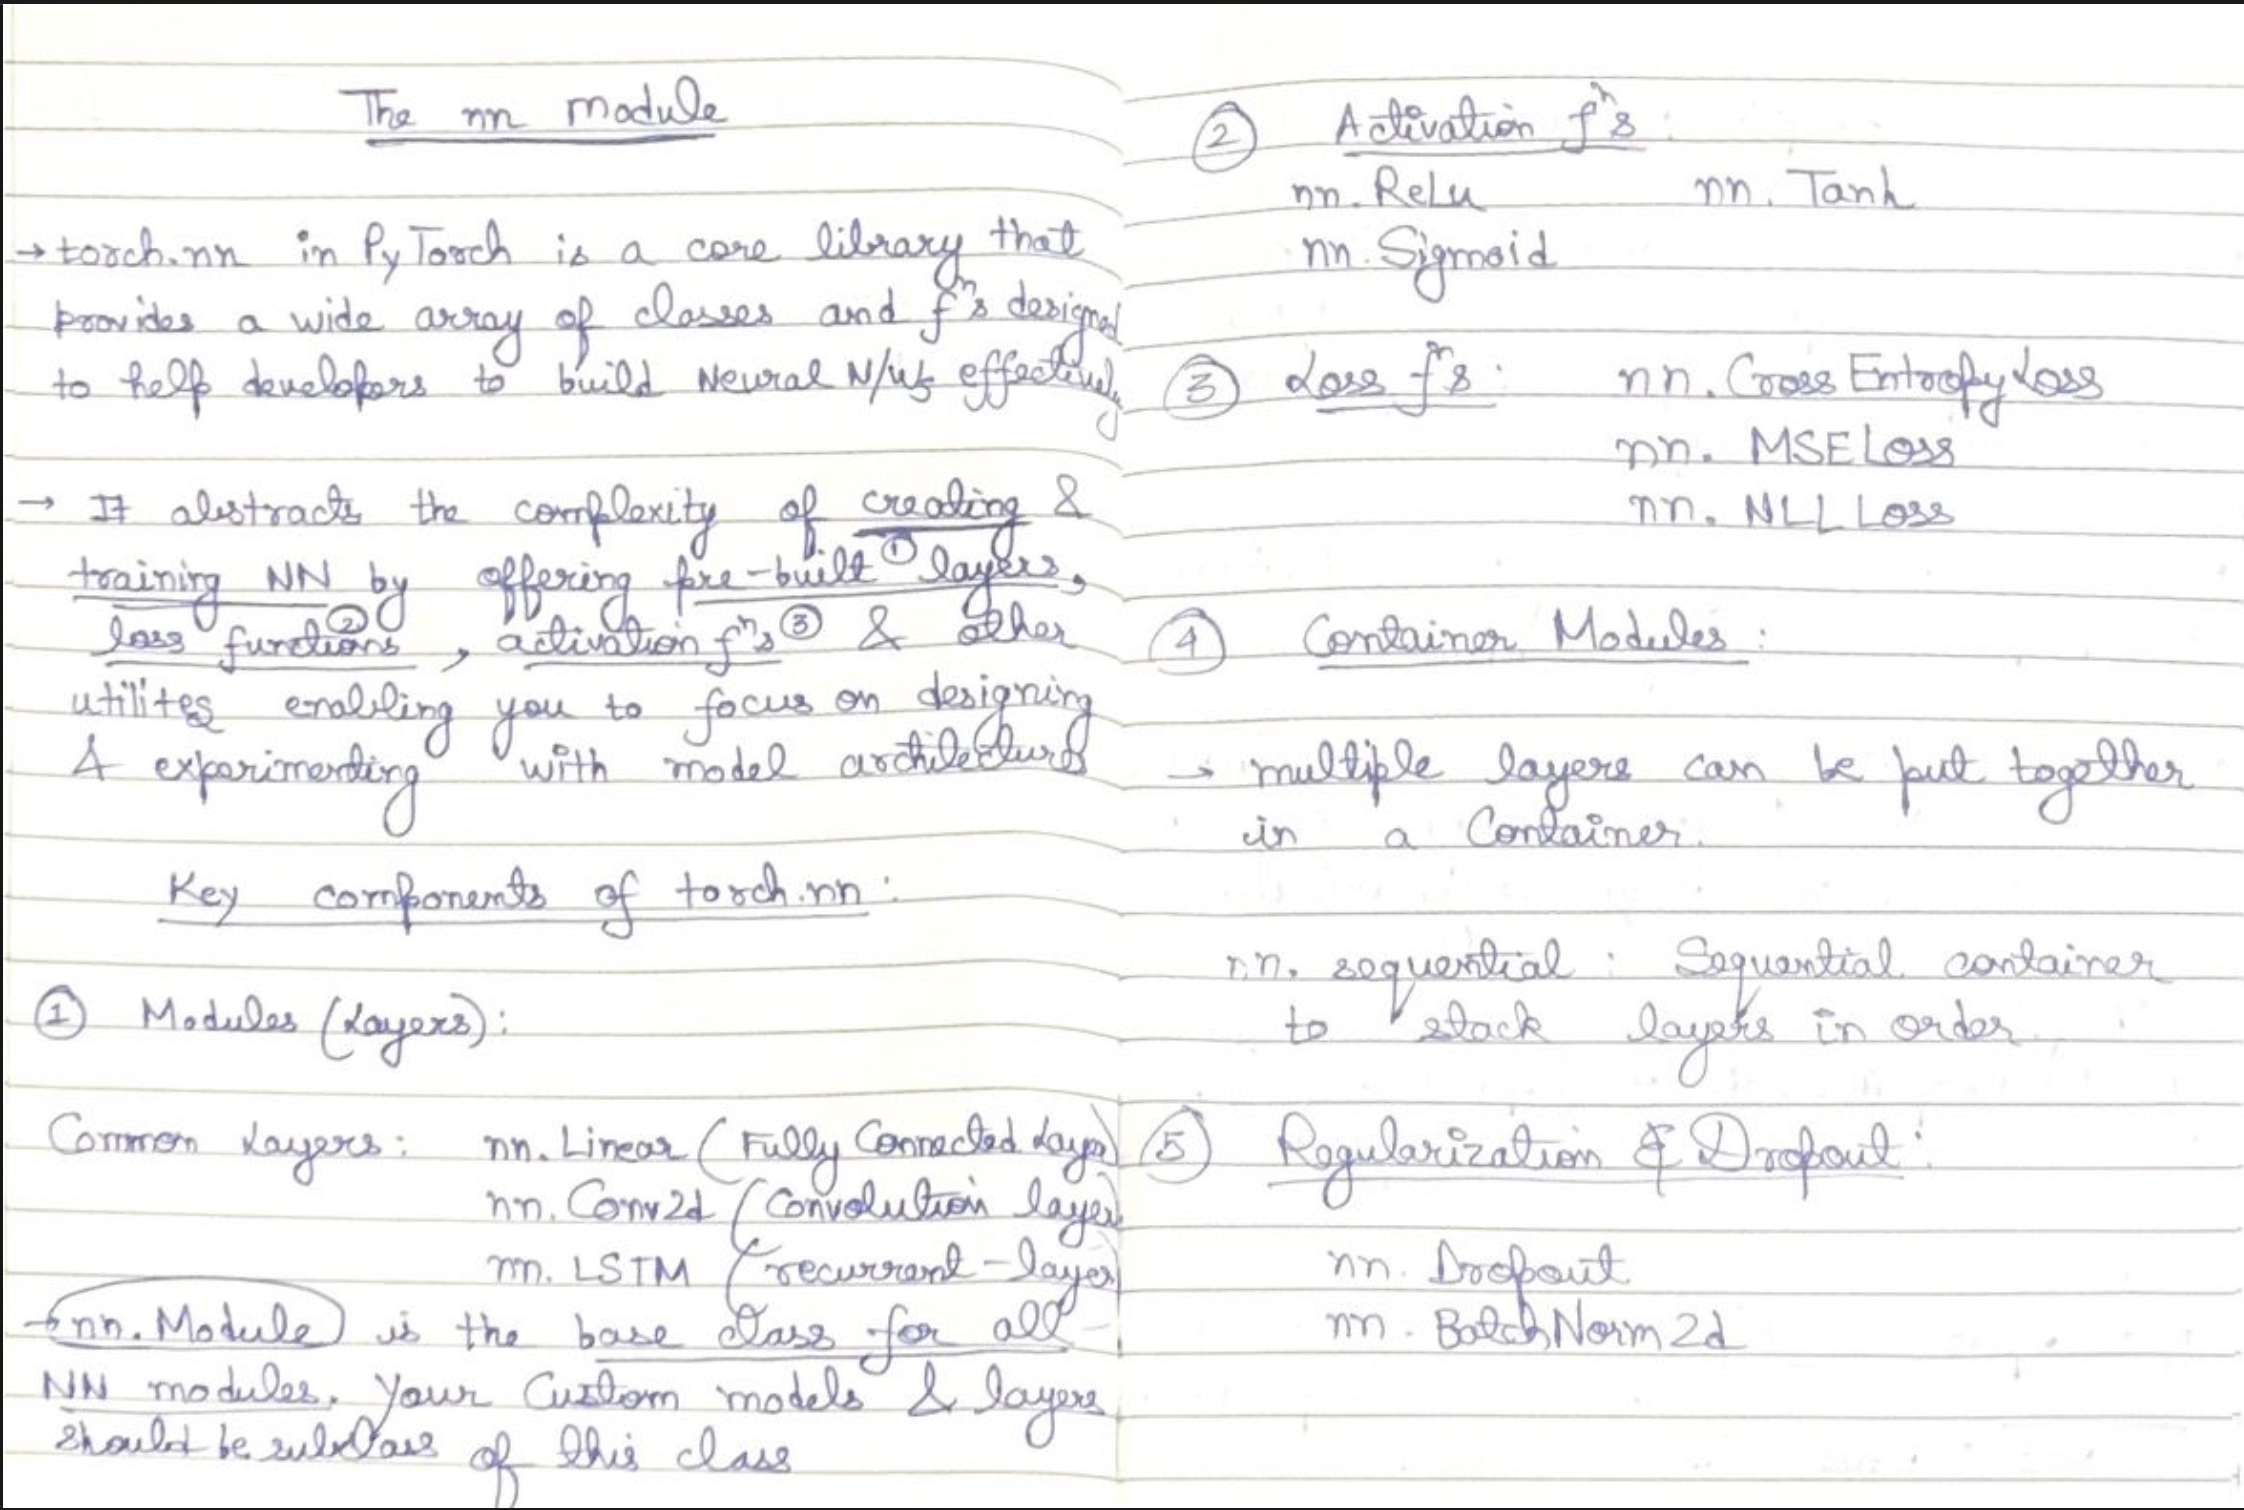

## torch.nn module

In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split

In [6]:
## we will have a neural network with binary classification problem, there will be 5 features

In [9]:
import torch
import torch.nn as nn


class Model(nn.Module):   ## nn.Module is the base class which has all the functionalities

  ## Developing architcture of NN in constructor
  def __init__(self,num_features):
    ## invoking parent class nn.Module through super keyword
    super().__init__()
    ## nn.Linear(no of inputs, no of outputs)
    self.linear=nn.Linear(num_features,1)
    self.sigmoid=nn.Sigmoid() ## activation function

  def forward(self,features):
    out=self.linear(features)## we will cal z here z=wx+b
    out=self.sigmoid(out)

    return out

In [10]:
## create a dataset
features =torch.rand(10,5) ## 10 rows and 5 features


## create a model

model=Model(features.shape[1])

In [11]:
## call model for forward pass


## we do not need to write model.forward(features)
## standard way of calling forward function
model(features)

tensor([[0.3887],
        [0.4214],
        [0.3202],
        [0.4532],
        [0.4604],
        [0.3463],
        [0.4356],
        [0.4467],
        [0.4055],
        [0.5074]], grad_fn=<SigmoidBackward0>)

In [ ]:
## show model weights
model.linear.weight

Parameter containing:
tensor([[-0.3314,  0.0119, -0.4391,  0.1105,  0.4455]], requires_grad=True)

In [13]:
model.linear

Linear(in_features=5, out_features=1, bias=True)

In [14]:
## show model bias
model.linear.bias

Parameter containing:
tensor([-0.1450], requires_grad=True)

In [15]:
!pip install torchinfo

## to visualize the nn

In [16]:
from torchinfo import summary


summary(model,input_size=(10,5))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [10, 1]                   --
├─Linear: 1-1                            [10, 1]                   6
├─Sigmoid: 1-2                           [10, 1]                   --
Total params: 6
Trainable params: 6
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

## Neural Networkw with one hidden layer

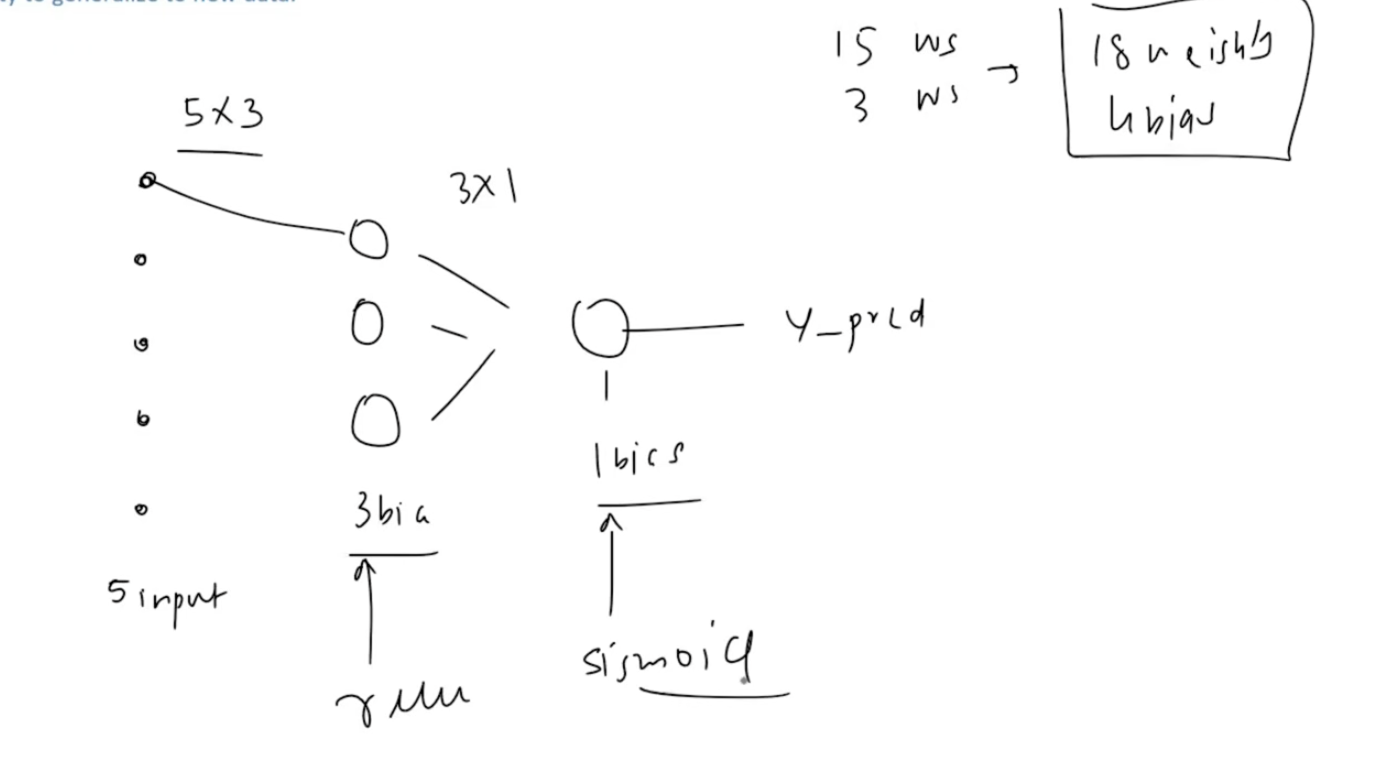

In [17]:
import torch
import torch.nn as nn


class Model(nn.Module):   ## nn.Module is the base class which has all the functionalities

  ## Developing architcture of NN in constructor
  def __init__(self,num_features):
    ## invoking parent class nn.Module through super keyword
    super().__init__()
    ## nn.Linear(no of inputs, no of outputs)
    self.linear1=nn.Linear(num_features,3)
    self.relu=nn.ReLU() ## activation function
    self.linear2=nn.Linear(3,1)
    self.sigmoid=nn.Sigmoid()

  def forward(self,features):
    out=self.linear1(features)## we will cal z here z=wx+b
    out=self.relu(out)
    out=self.linear2(out)
    out=self.sigmoid(out)

    return out

In [18]:
features =torch.rand(10,5)
model=Model(features.shape[1])
model(features)


tensor([[0.6281],
        [0.6243],
        [0.6022],
        [0.6171],
        [0.6520],
        [0.6171],
        [0.6195],
        [0.6480],
        [0.6337],
        [0.6146]], grad_fn=<SigmoidBackward0>)

In [20]:
model.linear1.weight

Parameter containing:
tensor([[-0.2554, -0.0280,  0.2806,  0.4163,  0.2804],
        [ 0.1580,  0.0539, -0.1113, -0.0427, -0.3740],
        [-0.0877, -0.4157, -0.0109,  0.3339,  0.1775]], requires_grad=True)

In [21]:
model.linear2.weight

Parameter containing:
tensor([[-0.5616,  0.5686,  0.3407]], requires_grad=True)

In [22]:
model.linear1.bias

Parameter containing:
tensor([-0.2891, -0.1899,  0.4350], requires_grad=True)

In [23]:
model.linear2.bias

Parameter containing:
tensor([0.4184], requires_grad=True)

In [25]:
from torchinfo import summary


summary(model,input_size=(10,5))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [10, 1]                   --
├─Linear: 1-1                            [10, 3]                   18
├─ReLU: 1-2                              [10, 3]                   --
├─Linear: 1-3                            [10, 1]                   4
├─Sigmoid: 1-4                           [10, 1]                   --
Total params: 22
Trainable params: 22
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

In [ ]:
class Model(nn.Module):  

  def __init__(self,num_features):
    super().__init__()
    self.linear1=nn.Linear(num_features,3)
    self.relu=nn.ReLU() 
    self.linear2=nn.Linear(3,1)
    self.sigmoid=nn.Sigmoid()

  def forward(self,features):
    out=self.linear1(features)
    out=self.relu(out)
    out=self.linear2(out)
    out=self.sigmoid(out)

    return out


## forward pass is very cumbersome
## for that we use sequential container

## Sequential Container

In [26]:
import torch
import torch.nn as nn


class Model(nn.Module):   ## nn.Module is the base class which has all the functionalities

  ## Developing architcture of NN in constructor
  def __init__(self,num_features):
    ## invoking parent class nn.Module through super keyword
    super().__init__()
    self.network=nn.Sequential(
        nn.Linear(num_features,3),
        nn.ReLU(),
        nn.Linear(3,1),
        nn.Sigmoid()
    )

  def forward(self,features):
    out=self.network(features)

    return out

In [27]:
features =torch.rand(10,5)
model=Model(features.shape[1])
model(features)


tensor([[0.4785],
        [0.4778],
        [0.4747],
        [0.4718],
        [0.4722],
        [0.4747],
        [0.4794],
        [0.4751],
        [0.4793],
        [0.4748]], grad_fn=<SigmoidBackward0>)

In [28]:
model.network

Sequential(
  (0): Linear(in_features=5, out_features=3, bias=True)
  (1): ReLU()
  (2): Linear(in_features=3, out_features=1, bias=True)
  (3): Sigmoid()
)

In [29]:
model.network[0]

Linear(in_features=5, out_features=3, bias=True)

In [30]:
model.network[0].weight

Parameter containing:
tensor([[ 0.4010,  0.3192,  0.2949,  0.0886, -0.1952],
        [-0.2462,  0.1348,  0.0616, -0.2522,  0.0144],
        [-0.2104,  0.1590, -0.4272, -0.2582,  0.2000]], requires_grad=True)

## Optimized Training Pipeline

In [31]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
import torch

In [32]:
df=pd.read_csv('https://raw.githubusercontent.com/gscdit/Breast-Cancer-Detection/refs/heads/master/data.csv')


In [33]:
df.drop(columns=['id','Unnamed: 32'],inplace=True)

In [34]:
X_train,X_test,y_train,y_test=train_test_split(df.iloc[:,1:],df.iloc[:,0],random_state=42,test_size=0.2)

In [35]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [36]:
encoder=LabelEncoder()
y_train=encoder.fit_transform(y_train)
y_test=encoder.transform(y_test)

In [37]:
X_train=torch.from_numpy(X_train)
X_test=torch.from_numpy(X_test)
y_train=torch.from_numpy(y_train)
y_test=torch.from_numpy(y_test)

In [38]:
X_train=X_train.to(torch.float32)
X_test=X_test.to(torch.float32)
y_train=y_train.to(torch.float32)
y_test=y_test.to(torch.float32)

In [39]:
learning_rate=0.1
epochs=25

In [40]:
class Model(nn.Module):
  def __init__(self,num_features):
    super().__init__()
    self.linear=nn.Linear(num_features,1)
    self.sigmoid=nn.Sigmoid()

  def forward(self,X):
    out=self.linear(X)
    out=self.sigmoid(out)
    return out

  def loss(self,y,y_pred):
    epsilon=1e-7
    y_pred=torch.clamp(y_pred,epsilon,1-epsilon)
    loss=-1*(y*torch.log(y_pred)+ (1-y) * torch.log(1-y_pred)).mean()
    return loss

In [41]:
model=Model(X_train.shape[1])
for epoch in range(epochs):
  y_pred=model(X_train)
  loss=model.loss(y_train,y_pred)
  loss.backward()
  with torch.no_grad():
    model.linear.weight-=learning_rate*(model.linear.weight.grad)
    model.linear.bias-=learning_rate*(model.linear.bias.grad)

  ## zero gradients
  model.linear.weight.grad.zero_()
  model.linear.bias.grad.zero_()
  print(loss)


tensor(0.7176, grad_fn=<MulBackward0>)
tensor(0.7139, grad_fn=<MulBackward0>)
tensor(0.7108, grad_fn=<MulBackward0>)
tensor(0.7081, grad_fn=<MulBackward0>)
tensor(0.7056, grad_fn=<MulBackward0>)
tensor(0.7033, grad_fn=<MulBackward0>)
tensor(0.7012, grad_fn=<MulBackward0>)
tensor(0.6992, grad_fn=<MulBackward0>)
tensor(0.6973, grad_fn=<MulBackward0>)
tensor(0.6955, grad_fn=<MulBackward0>)
tensor(0.6938, grad_fn=<MulBackward0>)
tensor(0.6922, grad_fn=<MulBackward0>)
tensor(0.6907, grad_fn=<MulBackward0>)
tensor(0.6893, grad_fn=<MulBackward0>)
tensor(0.6879, grad_fn=<MulBackward0>)
tensor(0.6866, grad_fn=<MulBackward0>)
tensor(0.6854, grad_fn=<MulBackward0>)
tensor(0.6842, grad_fn=<MulBackward0>)
tensor(0.6831, grad_fn=<MulBackward0>)
tensor(0.6821, grad_fn=<MulBackward0>)
tensor(0.6811, grad_fn=<MulBackward0>)
tensor(0.6802, grad_fn=<MulBackward0>)
tensor(0.6793, grad_fn=<MulBackward0>)
tensor(0.6784, grad_fn=<MulBackward0>)
tensor(0.6776, grad_fn=<MulBackward0>)


In [42]:
y_pred

tensor([[0.7504],
        [0.3251],
        [0.4577],
        [0.5147],
        [0.4962],
        [0.4890],
        [0.5797],
        [0.4400],
        [0.4687],
        [0.4318],
        [0.4492],
        [0.4147],
        [0.4591],
        [0.4851],
        [0.4750],
        [0.4438],
        [0.3762],
        [0.4778],
        [0.4445],
        [0.4929],
        [0.4494],
        [0.4077],
        [0.4601],
        [0.4250],
        [0.4286],
        [0.4974],
        [0.4580],
        [0.4355],
        [0.4285],
        [0.4374],
        [0.4327],
        [0.4836],
        [0.4791],
        [0.4430],
        [0.4422],
        [0.3997],
        [0.4619],
        [0.4152],
        [0.4532],
        [0.4714],
        [0.5090],
        [0.4985],
        [0.4633],
        [0.4857],
        [0.4463],
        [0.4292],
        [0.5187],
        [0.4666],
        [0.4486],
        [0.4133],
        [0.5429],
        [0.4446],
        [0.4559],
        [0.4678],
        [0.5099],
        [0

In [43]:
model.linear.weight

Parameter containing:
tensor([[-0.0970,  0.0408,  0.0764,  0.0727, -0.0482, -0.1011,  0.1190, -0.0462,
          0.0270, -0.0708,  0.0831,  0.0449,  0.0022, -0.0630, -0.1420, -0.0323,
          0.1107, -0.0337, -0.0180,  0.1312,  0.0508, -0.0230, -0.0204, -0.1176,
          0.1721, -0.0614,  0.0865, -0.1062,  0.0880, -0.1062]],
       requires_grad=True)

In [44]:
model.linear.bias

Parameter containing:
tensor([-0.2037], requires_grad=True)

In [45]:
with torch.no_grad():
  y_pred=(y_pred>0.5).float()
  accuracy=(y_pred==y_test).float().mean()
print(f'{accuracy.item():.4f}')

0.6012


# Optimizing Loss function and optimizer

In [46]:
class Model(nn.Module):
  def __init__(self,num_features):
    super().__init__()
    self.linear=nn.Linear(num_features,1)
    self.sigmoid=nn.Sigmoid()


  def forward(self,x):
    out=self.linear(x)
    out=self.sigmoid(out)
    return out

loss_function=nn.BCELoss() ## A callable loss function gets stored inside loss_function

In [47]:
print(type(loss_function))

<class 'torch.nn.modules.loss.BCELoss'>


In [48]:
model=Model(X_train.shape[1])
for epoch in range(epochs):
  y_pred=model(X_train)
  loss=loss_function(y_pred,y_train.view(-1, 1))
  loss.backward()
  with torch.no_grad():
    model.linear.weight-= learning_rate * (model.linear.weight.grad)
    model.linear.bias-= learning_rate * (model.linear.bias.grad)

  ## zero gradients
  model.linear.weight.grad.zero_()
  model.linear.bias.grad.zero_()
  print(loss)


tensor(0.8187, grad_fn=<BinaryCrossEntropyBackward0>)
tensor(0.6117, grad_fn=<BinaryCrossEntropyBackward0>)
tensor(0.5027, grad_fn=<BinaryCrossEntropyBackward0>)
tensor(0.4361, grad_fn=<BinaryCrossEntropyBackward0>)
tensor(0.3908, grad_fn=<BinaryCrossEntropyBackward0>)
tensor(0.3576, grad_fn=<BinaryCrossEntropyBackward0>)
tensor(0.3320, grad_fn=<BinaryCrossEntropyBackward0>)
tensor(0.3115, grad_fn=<BinaryCrossEntropyBackward0>)
tensor(0.2946, grad_fn=<BinaryCrossEntropyBackward0>)
tensor(0.2804, grad_fn=<BinaryCrossEntropyBackward0>)
tensor(0.2681, grad_fn=<BinaryCrossEntropyBackward0>)
tensor(0.2575, grad_fn=<BinaryCrossEntropyBackward0>)
tensor(0.2481, grad_fn=<BinaryCrossEntropyBackward0>)
tensor(0.2397, grad_fn=<BinaryCrossEntropyBackward0>)
tensor(0.2322, grad_fn=<BinaryCrossEntropyBackward0>)
tensor(0.2254, grad_fn=<BinaryCrossEntropyBackward0>)
tensor(0.2192, grad_fn=<BinaryCrossEntropyBackward0>)
tensor(0.2135, grad_fn=<BinaryCrossEntropyBackward0>)
tensor(0.2083, grad_fn=<Bina

In [49]:
with torch.no_grad():
  y_pred=(y_pred>0.5).float()
  accuracy=(y_pred==y_test).float().mean()
print(f'{accuracy.item():.4f}')

0.5316


## Optimizer

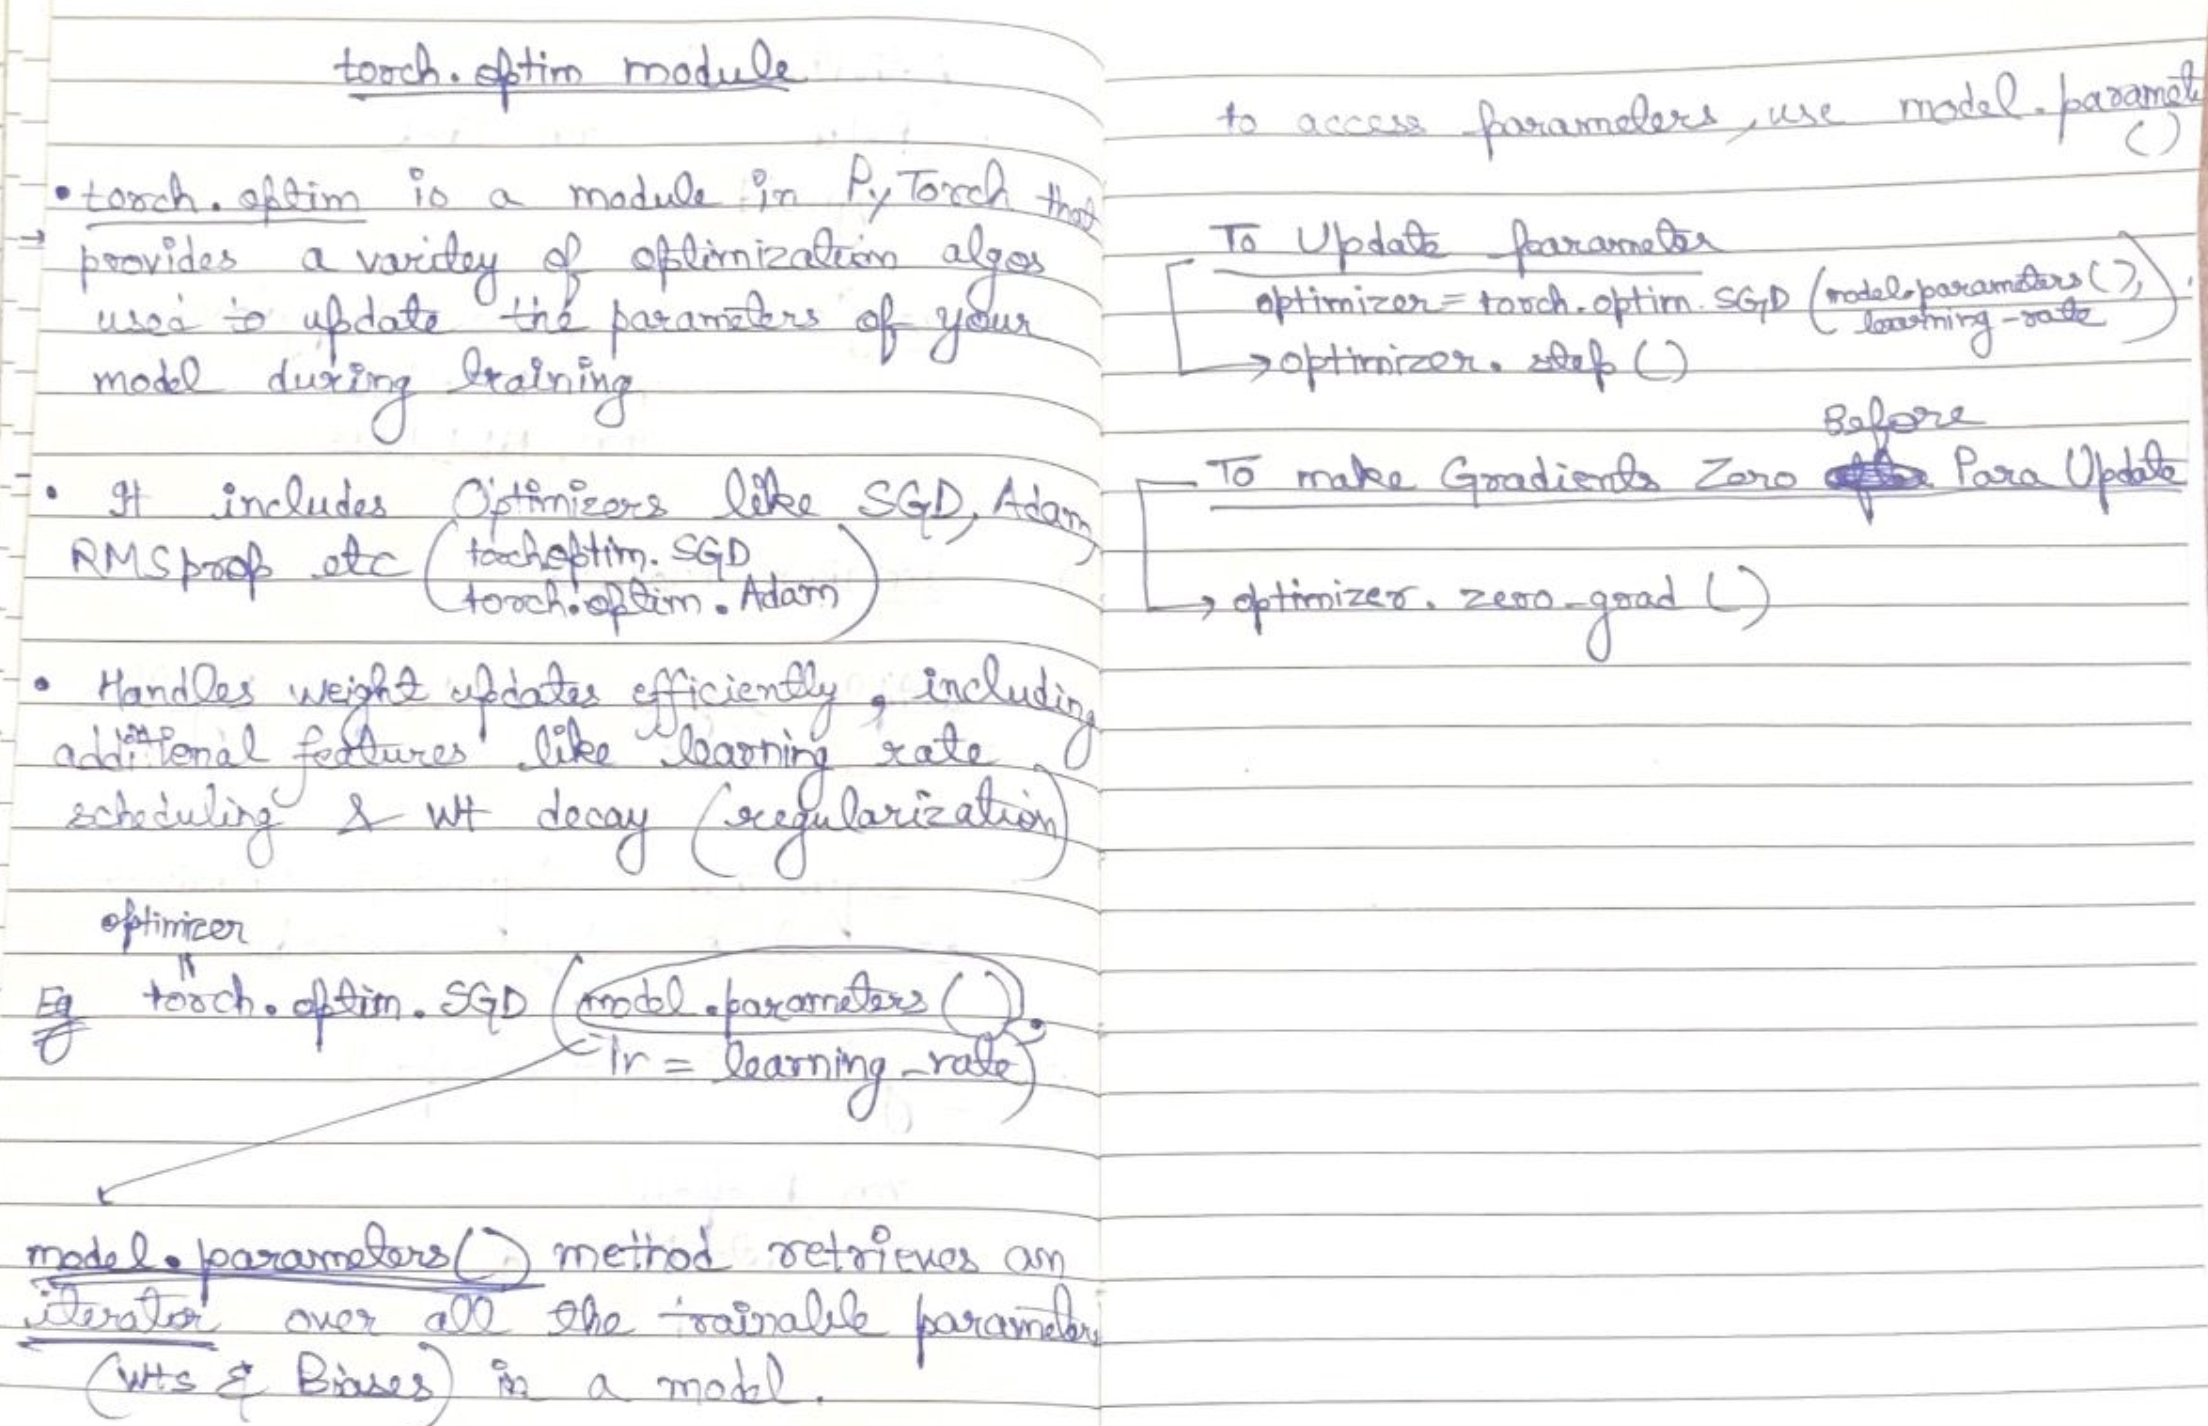

In [50]:
class Model(nn.Module):
  def __init__(self,num_features):
    super().__init__()
    self.linear=nn.Linear(num_features,1)
    self.sigmoid=nn.Sigmoid()


  def forward(self,x):
    out=self.linear(x)
    out=self.sigmoid(out)
    return out

loss_function=nn.BCELoss()
learning_rate=0.1
epochs=25
## Creating a model
model=Model(X_train.shape[1])

## define optimizer
optimizer=torch.optim.SGD(model.parameters(),lr=learning_rate)

## Training Pipeline

for epoch in range(epochs):

  ## Forward Pass
  y_pred=model(X_train)

  ## Loss Calculate
  loss=loss_function(y_pred,y_train.view(-1,1))

  ## Clear Gradients
  optimizer.zero_grad()


  ## Backward pass
  loss.backward()

  ## Parameters Update
  optimizer.step()

  ## print loss after each epoch
  print(f'Epoch:{epoch+1}, Loss:{loss.item()}')

Epoch:1, Loss:0.6639330387115479
Epoch:2, Loss:0.5348373651504517
Epoch:3, Loss:0.45828354358673096
Epoch:4, Loss:0.40791088342666626
Epoch:5, Loss:0.3716319799423218
Epoch:6, Loss:0.3438498079776764
Epoch:7, Loss:0.32166787981987
Epoch:8, Loss:0.30342403054237366
Epoch:9, Loss:0.28808292746543884
Epoch:10, Loss:0.27495822310447693
Epoch:11, Loss:0.2635728418827057
Epoch:12, Loss:0.25358256697654724
Epoch:13, Loss:0.24473153054714203
Epoch:14, Loss:0.23682467639446259
Epoch:15, Loss:0.22971037030220032
Epoch:16, Loss:0.22326864302158356
Epoch:17, Loss:0.2174031138420105
Epoch:18, Loss:0.2120354175567627
Epoch:19, Loss:0.20710110664367676
Epoch:20, Loss:0.202546626329422
Epoch:21, Loss:0.19832706451416016
Epoch:22, Loss:0.1944045126438141
Epoch:23, Loss:0.19074669480323792
Epoch:24, Loss:0.18732595443725586
Epoch:25, Loss:0.18411844968795776


In [17]:
## Evaluation

with torch.no_grad():
  y_pred=model(X_test)
  y_pred=(y_pred>0.5).float()
  accuracy=(y_pred==y_test).float().mean()

accuracy

tensor(0.5280)